In [1]:
import sys
import os
from qiskit import QuantumCircuit, transpile
from qiskit.providers.basic_provider import BasicSimulator
import numpy as np
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram

# Replace with your actual path
#cc_grn_functions_path = r"C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions"
cc_grn_functions_path = r"C:\Users\selim\Documents\vs_code_working_dir\QuantumXCT\python\cc_grn_functions"
sys.path.append(cc_grn_functions_path)

from quantum_functions import create_grn_ansatz, create_interaction_observable_from_histogram, evaluate_and_plot_ansatz
from quantum_functions import create_parameter_dictionaries, create_parameter_dictionaries_cust, cost_func_vqe, cost_func_wrapper, vqe_solver
from quantum_functions import create_interaction_observable_general, create_parameter_dictionaries_from_circuit, create_circuit_lr2

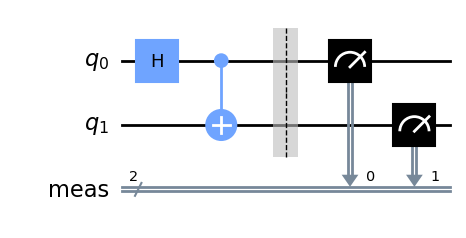

In [2]:
# 1. Create the Bell state (|ψ⟩ = (|00⟩ + |11⟩)/√2)
#circuit = QuantumCircuit(2, 2)
circuit = QuantumCircuit(2)
circuit.h(0)
circuit.cx(0, 1)

# 2. Define measurement bases (for a simple Bell test, we'll use the Z basis for both qubits)
# In a more complex Bell test, you would rotate the measurement bases.
#circuit.measure([0, 1], [0, 1])
circuit.measure_all()

# 3. Simulate the circuit for 1024 shots
simulator = BasicSimulator()
compiled_circuit = transpile(circuit, simulator)
job = simulator.run(compiled_circuit, shots=100)
result = job.result()
counts = result.get_counts(circuit)
circuit.draw(output="mpl", style="clifford", fold=40)

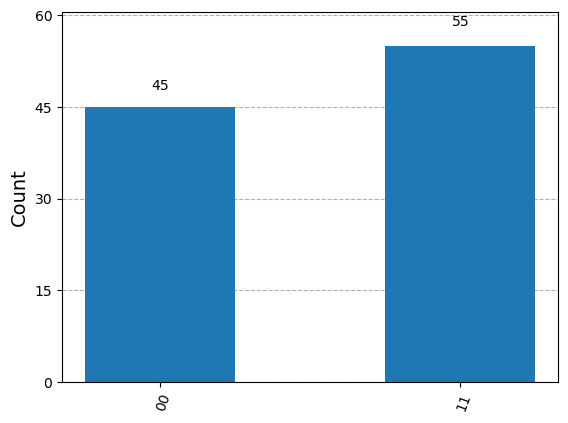

In [3]:
histogram_data = counts
hist_plt = plot_histogram(counts)
hist_plt

[3.14159265 3.14159265]


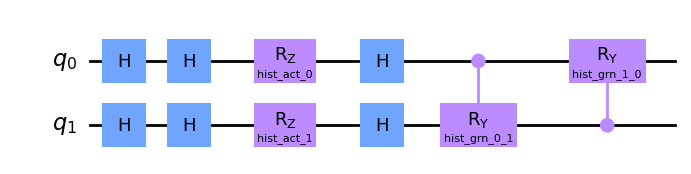

In [4]:
act_percentages = np.ones(circuit.num_qubits)*np.pi
print(act_percentages)
cirq = create_grn_ansatz(2, "hist")
cirq.draw(output="mpl", style="clifford", fold=40)

Interaction observable CT1 from histogram: SparsePauliOp(['II', 'IZ', 'ZI', 'ZZ'],
              coeffs=[-45.+0.j,   1.+0.j,   1.+0.j, -55.+0.j])
Static Parameters: {}
Variable Parameters (initialized to 0.0): {Parameter(hist_act_0): np.float64(3.141592653589793), Parameter(hist_act_1): np.float64(3.141592653589793), Parameter(hist_grn_0_1): np.float64(3.141592653589793), Parameter(hist_grn_1_0): np.float64(3.141592653589793)}
Starting optimization with method: COBYLA
Iteration 0: Current cost: -44.99999999999994
Iteration 20: Current cost: -100.88722016883833
Iteration 40: Current cost: -100.9999860956096

Optimization Result:
 message: Optimization terminated successfully.
 success: True
  status: 1
     fun: -100.9999998167834
       x: [ 3.311e+00  1.974e+00  1.571e+00  1.231e+00]
    nfev: 57
   maxcv: 0.0

Final Energy: -100.9999998167834

Optimized Full Parameters:
  hist_act_0: 3.3110169741766704
  hist_act_1: 1.9739139669457106
  hist_grn_0_1: 1.5709105279608202
  hist_grn_1_0

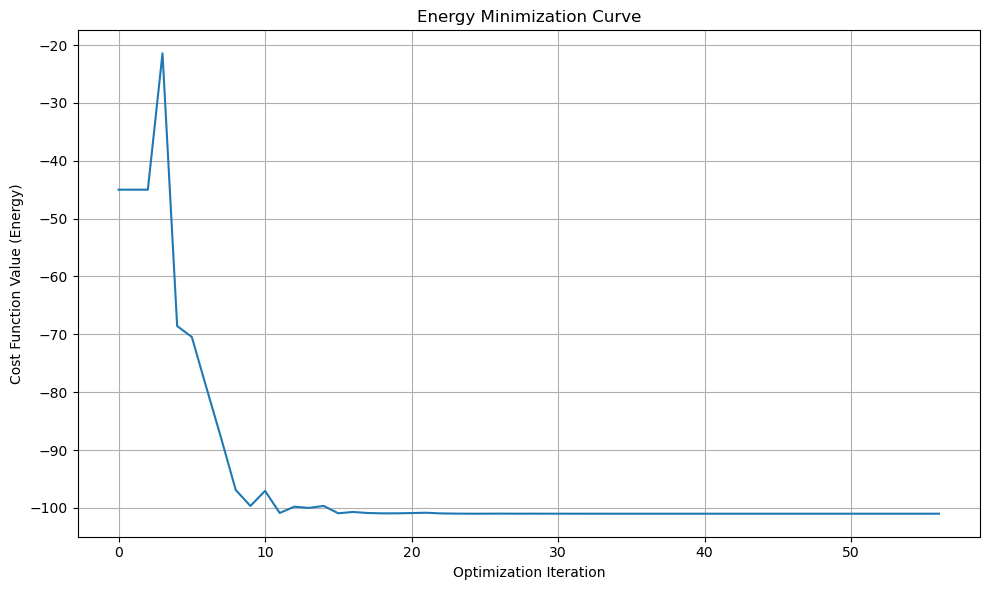

In [5]:
num_qubits = cirq.num_qubits # Get number of qubits from the circuit
min_ones = 0

result_interaction_bfgs, optimized_full_params, cost_values = vqe_solver(
    histogram_data,
    cirq, # Renamed from 'cirquit' for common convention
    act_percentages, # Renamed from 'act_percentages' for consistency with create_parameter_dictionaries_cust
    cost_func_wrapper, # This function needs to be defined to accept the correct arguments (see comments below)
    min_ones_obs=min_ones, # Added as an explicit argument for flexibility
    optimizer_method="COBYLA",# COBYLA | L-BFGS-B
)

# Plot the cost function values
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
plt.show()

The counts are: {'11': 787, '00': 237}


C:\Users\selim\Documents\vs_code_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:260: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


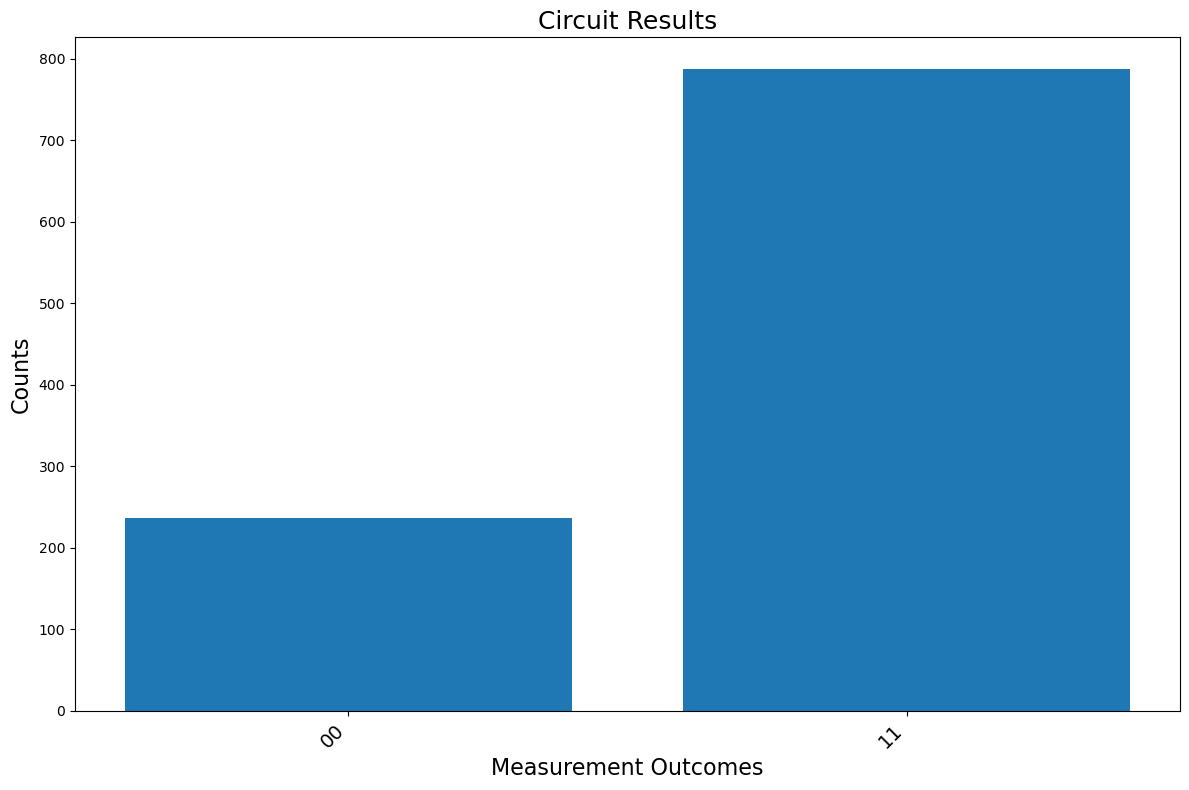

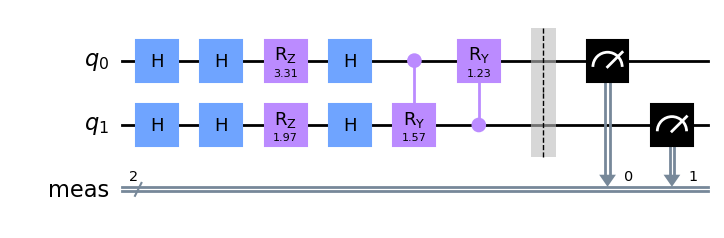

In [6]:
counts, bound_circuit = evaluate_and_plot_ansatz(cirq, optimized_full_params, shots=1024, title="Circuit Results")
bound_circuit.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

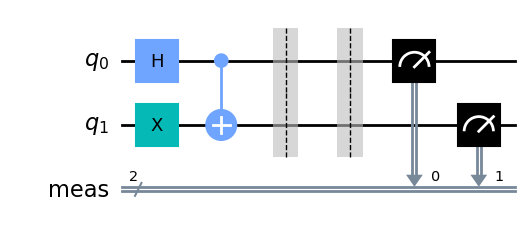

In [7]:
# 1. Create the Bell state (|ψ⟩ = (|00⟩ + |11⟩)/√2)
circuit = QuantumCircuit(2)
circuit.x(1)
circuit.h(0)
circuit.cx(0, 1)
circuit.barrier()

# 2. Define measurement bases (for a simple Bell test, we'll use the Z basis for both qubits)
# In a more complex Bell test, you would rotate the measurement bases.
#circuit.measure([0, 1], [0, 1])
circuit.measure_all()

# 3. Simulate the circuit for 1024 shots
simulator = BasicSimulator()
compiled_circuit = transpile(circuit, simulator)
job = simulator.run(compiled_circuit, shots=100)
result = job.result()
counts = result.get_counts(circuit)
circuit.draw(output="mpl", style="clifford", fold=40)

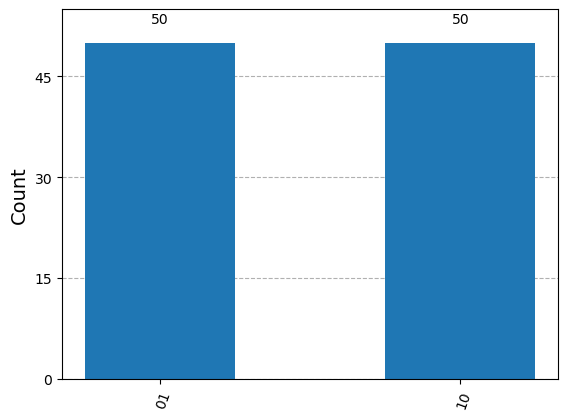

In [8]:
histogram_data = counts
hist_plt = plot_histogram(counts)
hist_plt

[3.14159265 3.14159265]


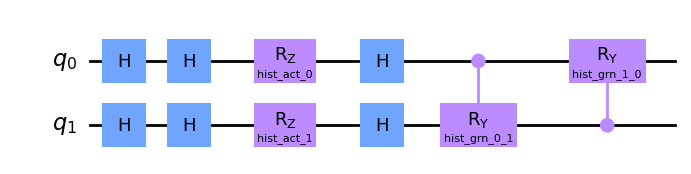

In [9]:
act_percentages = np.ones(circuit.num_qubits)*np.pi
print(act_percentages)
cirq = create_grn_ansatz(2, "hist")
cirq.draw(output="mpl", style="clifford", fold=40)

Interaction observable CT1 from histogram: SparsePauliOp(['II', 'IZ', 'ZI', 'ZZ'],
              coeffs=[  1.+0.j, -50.+0.j, -50.+0.j,   1.+0.j])
Static Parameters: {}
Variable Parameters (initialized to 0.0): {Parameter(hist_act_0): np.float64(3.141592653589793), Parameter(hist_act_1): np.float64(3.141592653589793), Parameter(hist_grn_0_1): np.float64(3.141592653589793), Parameter(hist_grn_1_0): np.float64(3.141592653589793)}
Starting optimization with method: COBYLA
Iteration 0: Current cost: 1.0
Iteration 20: Current cost: -24.47199362826996
Iteration 40: Current cost: -24.499965949296044
Iteration 60: Current cost: -24.49999973561885

Optimization Result:
 message: Optimization terminated successfully.
 success: True
  status: 1
     fun: -24.499999886531352
       x: [ 4.859e+00  2.780e+00  4.438e+00  5.901e+00]
    nfev: 72
   maxcv: 0.0

Final Energy: -24.499999886531352

Optimized Full Parameters:
  hist_act_0: 4.859364411789525
  hist_act_1: 2.780045256424305
  hist_grn_0_1: 4

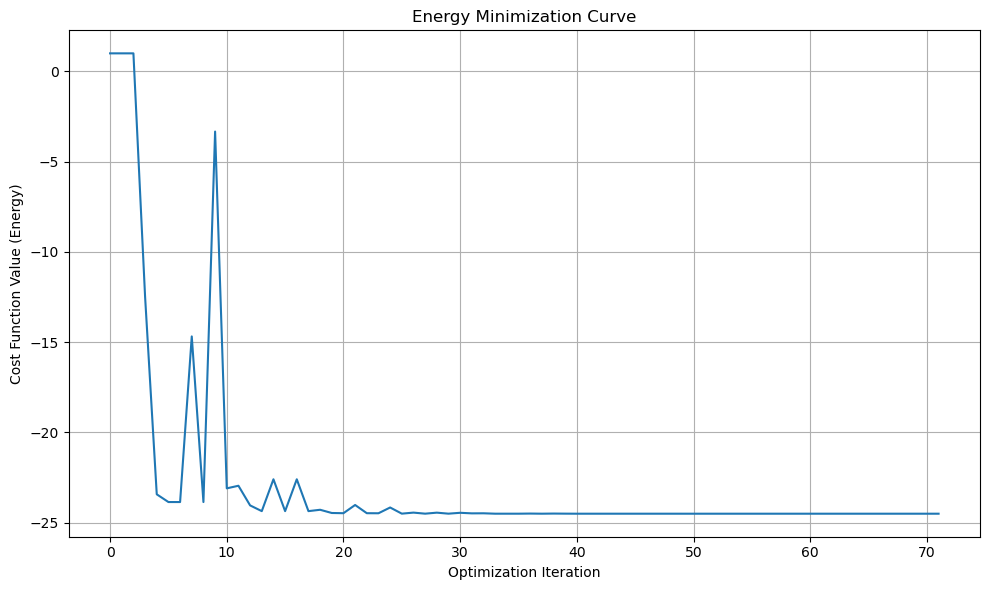

In [10]:
num_qubits = cirq.num_qubits # Get number of qubits from the circuit
min_ones = 0

result_interaction_bfgs, optimized_full_params, cost_values = vqe_solver(
    histogram_data,
    cirq, # Renamed from 'cirquit' for common convention
    act_percentages, # Renamed from 'act_percentages' for consistency with create_parameter_dictionaries_cust
    cost_func_wrapper, # This function needs to be defined to accept the correct arguments (see comments below)
    min_ones_obs=min_ones, # Added as an explicit argument for flexibility
    optimizer_method="COBYLA",# COBYLA | L-BFGS-B
)

# Plot the cost function values
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
plt.show()

The counts are: {'01': 506, '10': 254, '00': 264}


C:\Users\selim\Documents\vs_code_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:260: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


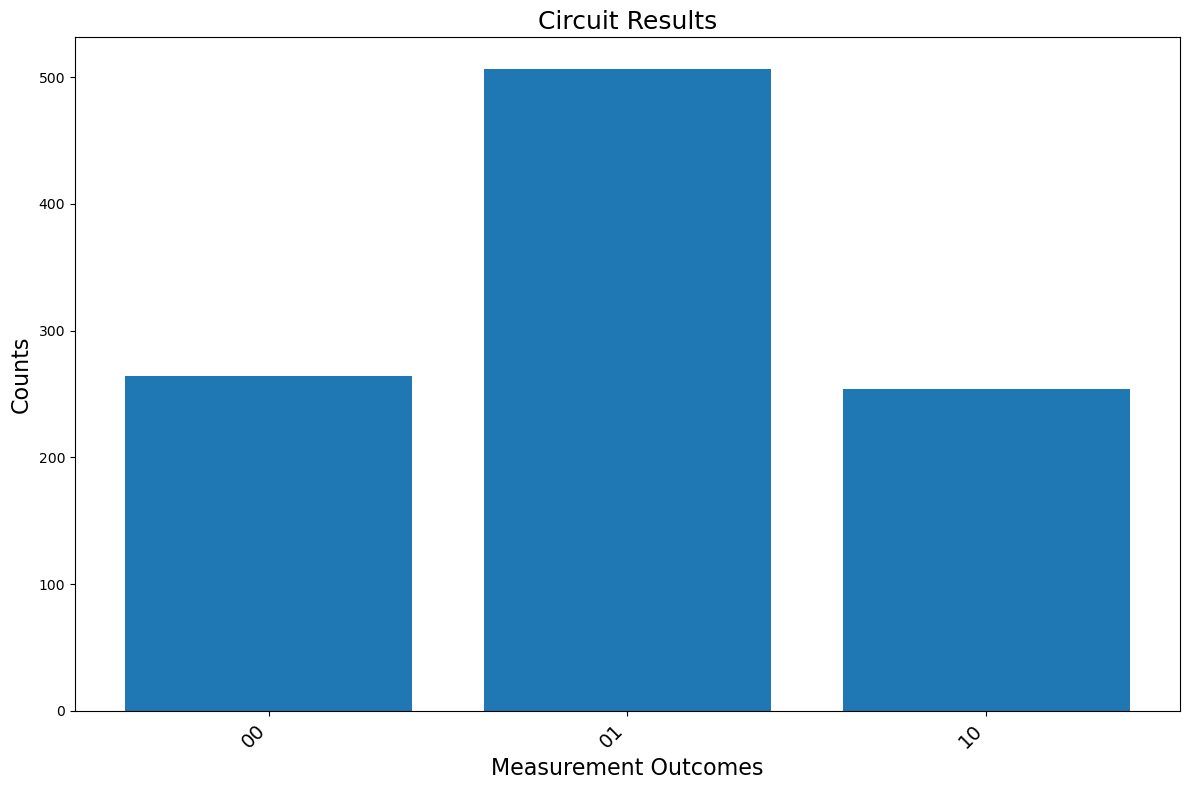

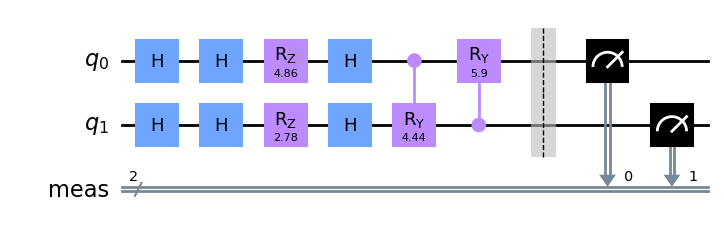

In [11]:
counts, bound_circuit = evaluate_and_plot_ansatz(cirq, optimized_full_params, shots=1024, title="Circuit Results")
bound_circuit.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

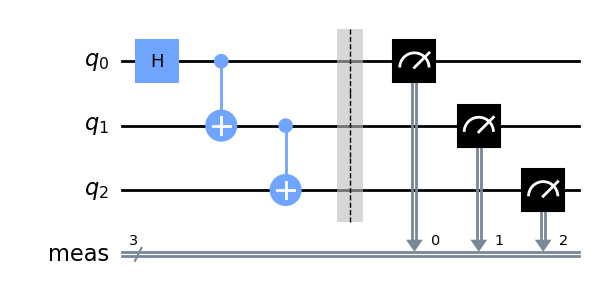

In [12]:
from qiskit import QuantumCircuit, transpile
from qiskit.providers.basic_provider import BasicSimulator
import numpy as np
import matplotlib.pyplot as plt

# 1. Create the 3-qubit GHZ-like state
# |ψ⟩ = (|000⟩ + |111⟩)/√2
circuit = QuantumCircuit(3) # Initialize with 3 qubits and 3 classical bits

circuit.h(0)
#circuit.h(1)
#circuit.h(2)
#circuit.h(3)
#circuit.x(1)
#circuit.x(2)
circuit.cx(0, 1)
circuit.cx(1, 2)
#circuit.cx(2, 3)

# 2. Measure all three qubits
circuit.measure_all()

# 3. Simulate the circuit for 1024 shots
simulator = BasicSimulator()
compiled_circuit = transpile(circuit, simulator)
job = simulator.run(compiled_circuit, shots=1024)
result = job.result()
counts = result.get_counts(circuit)
circuit.draw(output="mpl", style="clifford", fold=40)


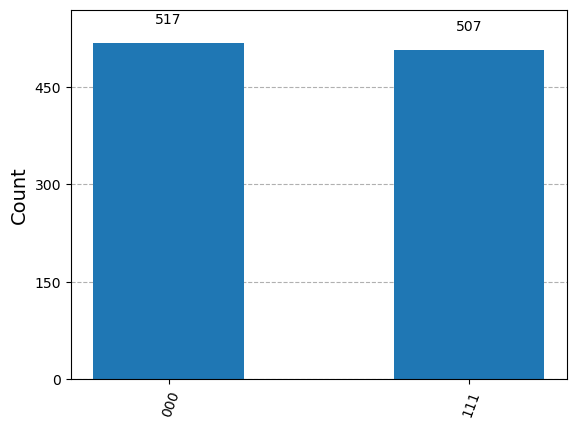

In [13]:
histogram_data = counts
hist_plt = plot_histogram(counts)
hist_plt

[3.14159265 3.14159265 3.14159265]


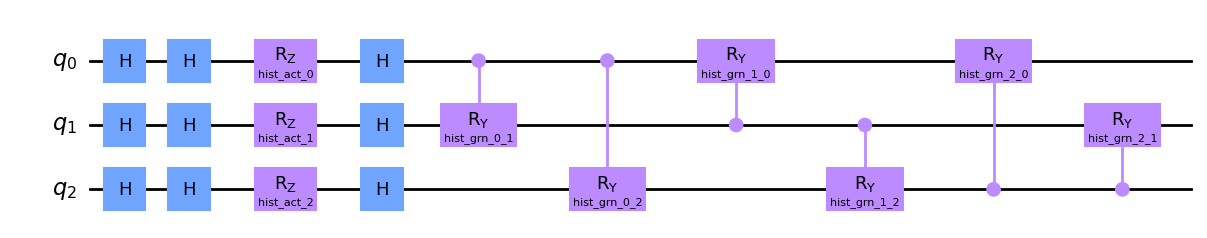

In [14]:
act_percentages = np.ones(circuit.num_qubits)*np.pi
print(act_percentages)
cirq = create_grn_ansatz(circuit.num_qubits, "hist")
cirq.draw(output="mpl", style="clifford", fold=40)

Interaction observable CT1 from histogram: SparsePauliOp(['III', 'IIZ', 'IZI', 'IZZ', 'ZII', 'ZIZ', 'ZZI', 'ZZZ'],
              coeffs=[-517.+0.j,    1.+0.j,    1.+0.j,    1.+0.j,    1.+0.j,    1.+0.j,
    1.+0.j, -507.+0.j])
Static Parameters: {}
Variable Parameters (initialized to 0.0): {Parameter(hist_act_0): np.float64(3.141592653589793), Parameter(hist_act_1): np.float64(3.141592653589793), Parameter(hist_act_2): np.float64(3.141592653589793), Parameter(hist_grn_0_1): np.float64(3.141592653589793), Parameter(hist_grn_0_2): np.float64(3.141592653589793), Parameter(hist_grn_1_0): np.float64(3.141592653589793), Parameter(hist_grn_1_2): np.float64(3.141592653589793), Parameter(hist_grn_2_0): np.float64(3.141592653589793), Parameter(hist_grn_2_1): np.float64(3.141592653589793)}
Starting optimization with method: COBYLA
Iteration 0: Current cost: -516.999999999999
Iteration 20: Current cost: -885.3937377347934
Iteration 40: Current cost: -993.5261262511557
Iteration 60: Current cost: -

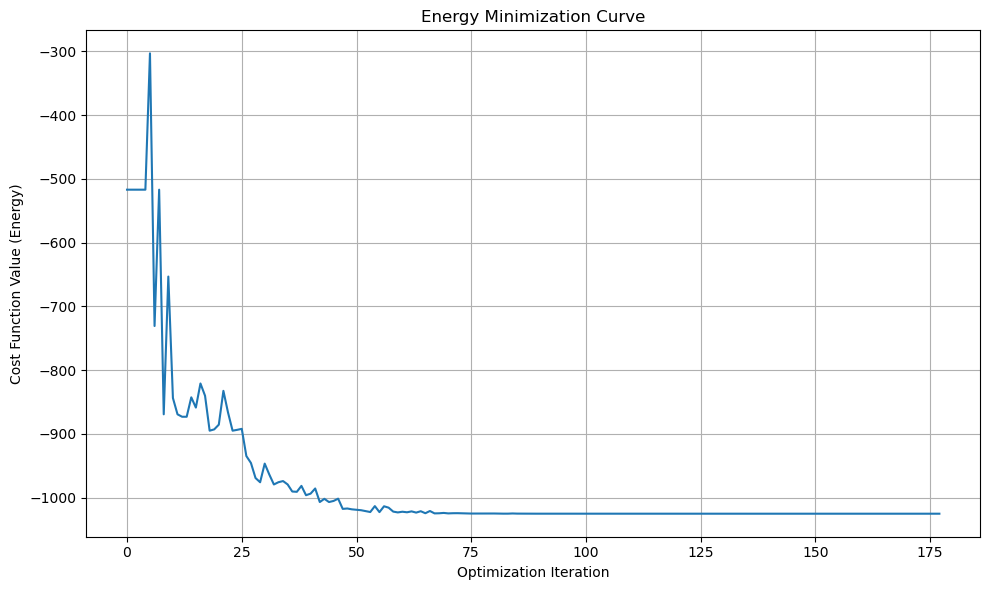

In [15]:
num_qubits = cirq.num_qubits # Get number of qubits from the circuit
min_ones = 0

result_interaction_bfgs, optimized_full_params, cost_values = vqe_solver(
    histogram_data,
    cirq, # Renamed from 'cirquit' for common convention
    act_percentages, # Renamed from 'act_percentages' for consistency with create_parameter_dictionaries_cust
    cost_func_wrapper, # This function needs to be defined to accept the correct arguments (see comments below)
    min_ones_obs=min_ones, # Added as an explicit argument for flexibility
    optimizer_method="COBYLA",# COBYLA | L-BFGS-B
)

# Plot the cost function values
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
plt.show()

The counts are: {'000': 136, '101': 612, '011': 276}


C:\Users\selim\Documents\vs_code_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:260: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


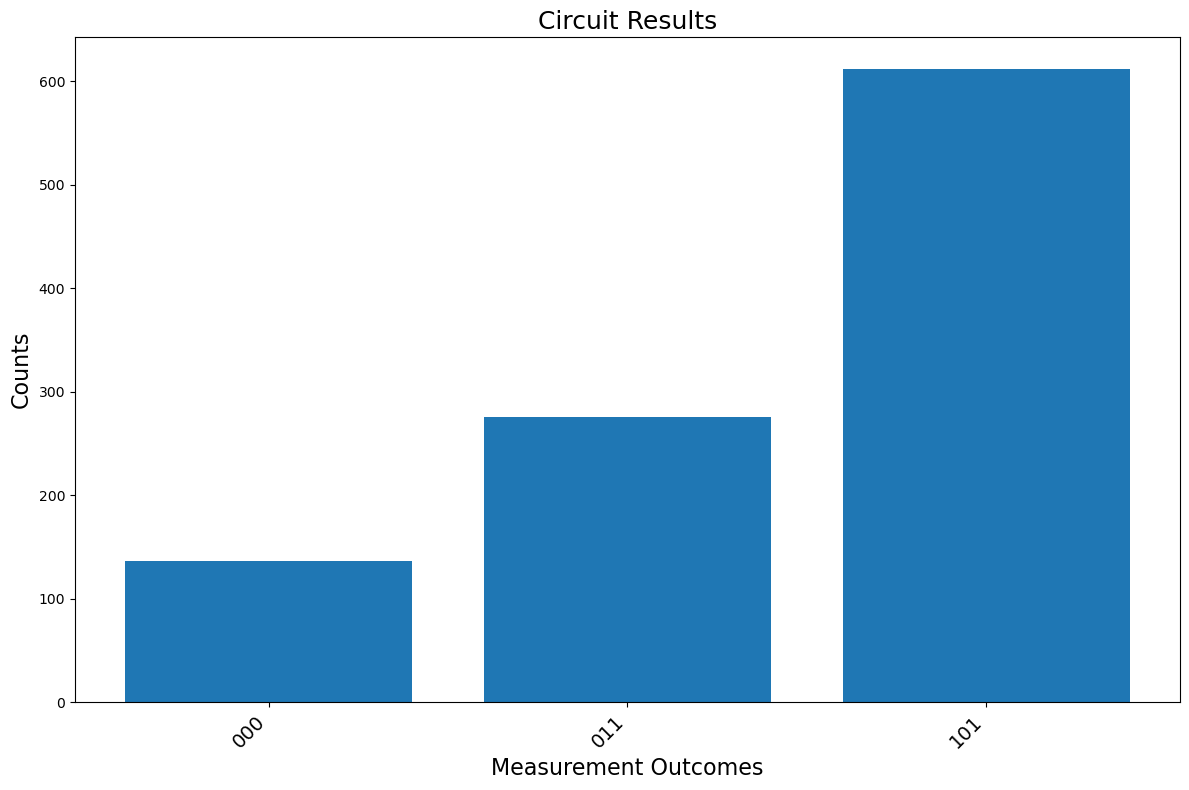

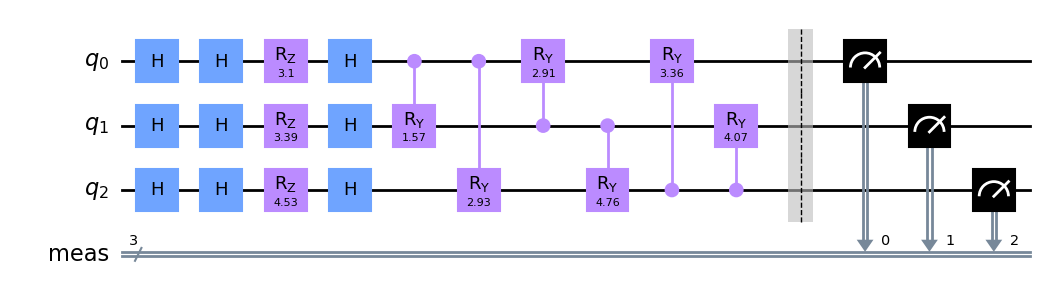

In [16]:
counts, bound_circuit = evaluate_and_plot_ansatz(cirq, optimized_full_params, shots=1024, title="Circuit Results")
bound_circuit.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot


Circuit Diagram (with Parameters):


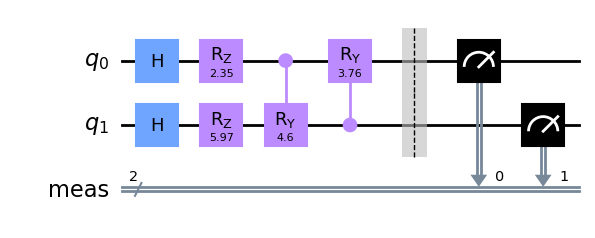

In [17]:
from qiskit import QuantumCircuit, transpile
from qiskit.providers.basic_provider import BasicSimulator
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit import Parameter # Import Parameter

# Set a random seed for reproducibility of angles
np.random.seed(42)

# Function to generate a random numerical value for parameters
def get_random_parameter_value():
    return np.random.uniform(0, 2 * np.pi)

# --- Define the number of qubits here ---
num_qubits = 2 # You can change this value to any desired number of qubits

# 1. Create the quantum circuit
# Initialize with num_qubits quantum bits and num_qubits classical bits
circuit = QuantumCircuit(num_qubits)
# num_features is now directly equivalent to num_qubits
num_features = circuit.num_qubits

# Dictionary to store all parameters and their initial static values
parameter_values = {}
all_qiskit_parameters = [] # To keep track of the Parameter objects created

# Define parameters for the initial Rz gates (activation parameters)
params_act = [Parameter(f"act_{i}") for i in range(num_features)]
for param in params_act:
    parameter_values[param] = get_random_parameter_value()
    all_qiskit_parameters.append(param)

# Define a placeholder for cell_type, as it was not defined in your snippet
cell_type = "ex_cell"

# --- Circuit Construction ---

# Apply Hadamard gates and Rz rotations to each qubit
for i in range(num_features):
    circuit.h(i)
    circuit.rz(params_act[i], i)  # Use RZ for activation with defined parameters

# Gene interaction CRy gates
# This loop structure creates CRy gates between all unique ordered pairs of qubits
for i in range(num_features):
    for j in range(num_features):
        if i != j:
            param_name = f'{cell_type}_grn_{i}_{j}'
            param = Parameter(param_name)
            circuit.cry(param, i, j) # Using CRy as per your snippet
            parameter_values[param] = get_random_parameter_value() # Assign a static random value
            all_qiskit_parameters.append(param)

# 2. Measure all qubits
# This is a more general way to measure all qubits into all classical bits
circuit.measure_all()

# 3. Simulate the circuit for 1024 shots
simulator = BasicSimulator()

# IMPORTANT: Assign the static random values to the parameters
# This creates a new circuit where all parameters are replaced by their numerical values.
bound_circuit = circuit.assign_parameters(parameter_values)

# Transpile and run the bound circuit
compiled_circuit = transpile(bound_circuit, simulator)
job = simulator.run(compiled_circuit, shots=1024)
result = job.result()
counts = result.get_counts(bound_circuit) # Get counts from the bound circuit
# Draw the circuit
print("\nCircuit Diagram (with Parameters):")
# Draw the original circuit with parameters for clarity, before binding
bound_circuit.draw(output="mpl", style="clifford", fold=40)

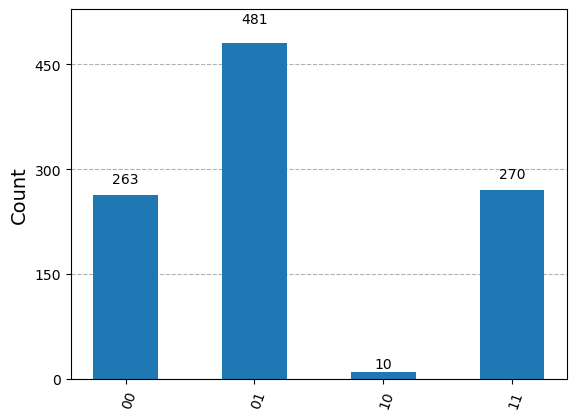

In [18]:
histogram_data = counts
hist_plt = plot_histogram(counts)
hist_plt

[3.14159265 3.14159265]


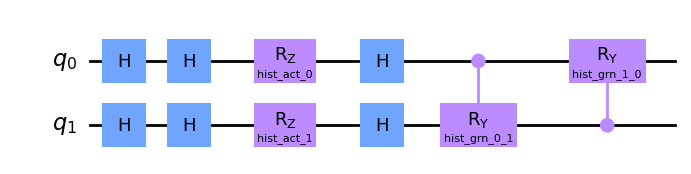

In [19]:
act_percentages = np.ones(num_qubits)*np.pi
#act_percentages = np.array([2.35, 5.97])
print(act_percentages)
cirq = create_grn_ansatz(num_qubits, "hist")
cirq.draw(output="mpl", style="clifford", fold=40)

Interaction observable from histogram: SparsePauliOp(['IZ', 'ZI', 'ZZ'],
              coeffs=[-481.+0.j,  -10.+0.j, -270.+0.j])
Static Parameters: {}
Variable Parameters (initialized to 0.0): {Parameter(hist_act_0): np.float64(3.141592653589793), Parameter(hist_act_1): np.float64(3.141592653589793), Parameter(hist_grn_0_1): np.float64(3.141592653589793), Parameter(hist_grn_1_0): np.float64(3.141592653589793)}

Optimization Result:
 message: Optimization terminated successfully.
 success: True
  status: 1
     fun: -340.99999913053347
       x: [ 3.107e+00  2.728e+00  1.571e+00  4.373e+00]
    nfev: 60
   maxcv: 0.0

Optimized Full Parameters:
  hist_act_0: 3.107371305200884
  hist_act_1: 2.728028004973293
  hist_grn_0_1: 1.5707521881825097
  hist_grn_1_0: 4.372642011533804


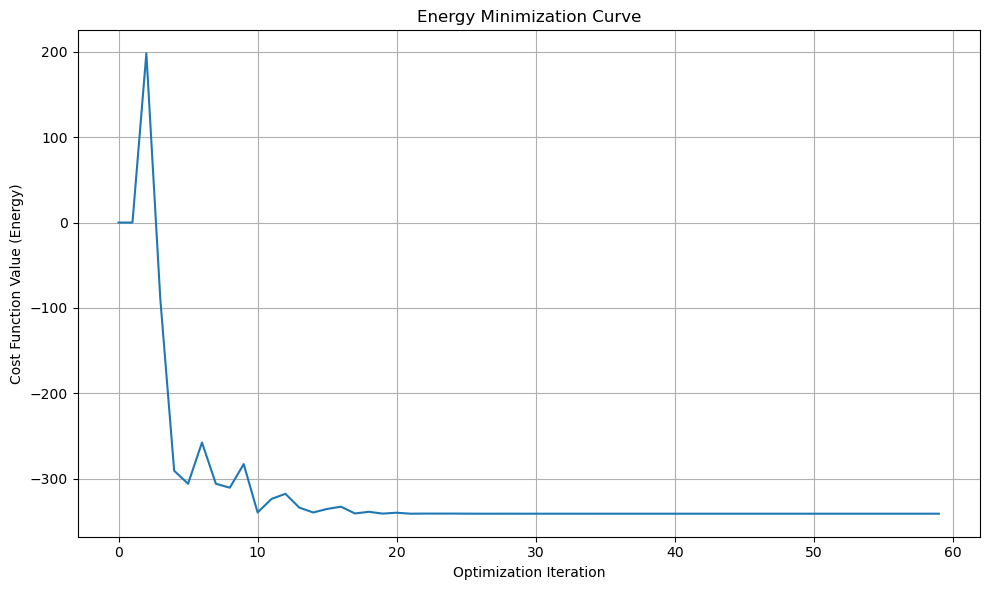

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize

# Get number of qubits from the circuit
min_ones = 1
# 1. Create interaction observable
interaction_observable = create_interaction_observable_from_histogram( joint_counts=histogram_data, 
                                                                      num_features=num_qubits, 
                                                                      min_ones=min_ones)
print("Interaction observable from histogram:", interaction_observable)

# 2. Create static and variable parameter dictionaries
# Ensure you are using create_parameter_dictionaries_cust here, not create_parameter_dictionaries
#static_params, variable_params = create_parameter_dictionaries(cirq, act_percentages)
static_params, variable_params = create_parameter_dictionaries_cust(cirq, act_percentages)


print("Static Parameters:", static_params)
print("Variable Parameters (initialized to 0.0):", variable_params)

# 3. Initialize Qiskit Estimator
estimator = StatevectorEstimator()

# 4. Prepare initial guess for optimization
x0_interaction = np.array(list(variable_params.values()))
variable_param_objects = list(variable_params.keys())

# 5. Create initial full parameter dictionary (this is mainly for initial print and structure)
all_params = static_params.copy()
all_params.update(dict(zip(variable_param_objects, x0_interaction)))

cost_values = []
# Call minimize with args
result_interaction_bfgs = minimize(
    cost_func_wrapper,
    x0_interaction,
    args=(all_params, cirq, interaction_observable, estimator, variable_params), # Pass all the arguments as a tuple
    method="COBYLA", # COBYLA | L-BFGS-B
    callback=lambda xk: cost_values.append(cost_func_wrapper(xk, all_params, cirq, interaction_observable, estimator, variable_params))
)

print("\nOptimization Result:")
print(result_interaction_bfgs)

# 7. Update the full parameter dictionary with optimized variable parameters
optimized_variable_parameters = result_interaction_bfgs.x

# Construct the final optimized full parameter dictionary
optimized_full_params = static_params.copy()
for param_obj, value in zip(variable_param_objects, optimized_variable_parameters):
    optimized_full_params[param_obj] = value

print("\nOptimized Full Parameters:")
# Print optimized parameters by name for readability
for param, value in optimized_full_params.items():
    print(f"  {param.name}: {value}")

import matplotlib.pyplot as plt

# Plot the cost function values
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
plt.show()

The counts are: {'10': 752, '00': 272}


C:\Users\selim\Documents\vs_code_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:260: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


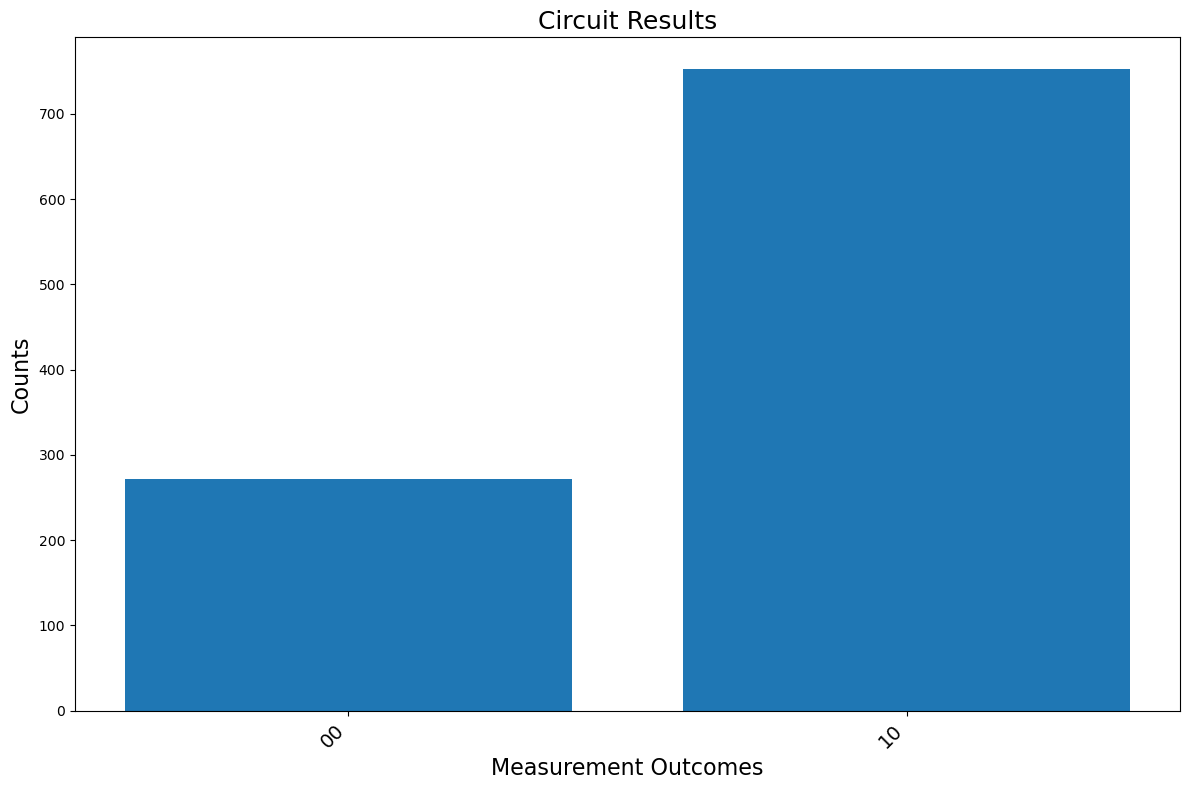

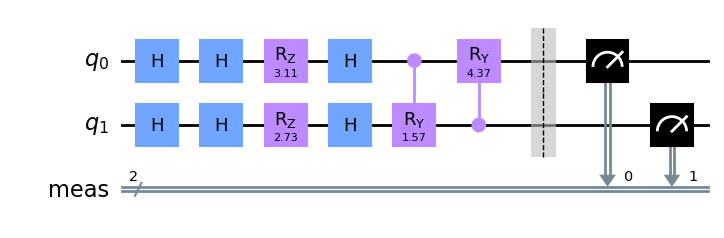

In [21]:
counts, bound_circuit = evaluate_and_plot_ansatz(cirq, optimized_full_params, shots=1024, title="Circuit Results")

bound_circuit.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

In [ ]:
# 1. Create the Bell state (|ψ⟩ = (|00⟩ + |11⟩)/√2)
#circuit = QuantumCircuit(2, 2)
circuit = QuantumCircuit(1))
circuit.h(0)
#circuit.cx(0, 1)

# 2. Define measurement bases (for a simple Bell test, we'll use the Z basis for both qubits)
# In a more complex Bell test, you would rotate the measurement bases.
#circuit.measure([0, 1], [0, 1])
circuit.measure_all()

# 3. Simulate the circuit for 1024 shots
simulator = BasicSimulator()
compiled_circuit = transpile(circuit, simulator)
job = simulator.run(compiled_circuit, shots=100)
result = job.result()
counts = result.get_counts(circuit)
circuit.draw(output="mpl", style="clifford", fold=40)

In [ ]:
histogram_data = counts
hist_plt = plot_histogram(counts)
hist_plt

In [ ]:
num_qubits = cirq.num_qubits # Get number of qubits from the circuit
min_ones = 0

result_interaction_bfgs, optimized_full_params, cost_values = vqe_solver(
    histogram_data,
    cirq, # Renamed from 'cirquit' for common convention
    act_percentages, # Renamed from 'act_percentages' for consistency with create_parameter_dictionaries_cust
    cost_func_wrapper, # This function needs to be defined to accept the correct arguments (see comments below)
    min_ones_obs=min_ones, # Added as an explicit argument for flexibility
    optimizer_method="COBYLA",# COBYLA | L-BFGS-B
)

# Plot the cost function values
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
counts, bound_circuit = evaluate_and_plot_ansatz(cirq, optimized_full_params, shots=1024, title="Circuit Results")

bound_circuit.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot